In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc
from opacus import PrivacyEngine


transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


In [3]:
print(train_loader.dataset.data.shape)

torch.Size([60000, 28, 28])


MODEL

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()


gc.collect()

/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


813

In [5]:
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0 
)

epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/10]
Training loss 0.9743752934035911
Training accuracy 70.61682367431177 %
Testing loss 5.854241637827456
Testing accuracy 86.32 %
Epoch [2/10]
Training loss 0.40818780685710015
Training accuracy 88.19888178913737 %
Testing loss 2.453045444088429
Testing accuracy 89.83 %
Epoch [3/10]
Training loss 0.3405514006929226
Training accuracy 90.33124291146841 %
Testing loss 2.0418099779944865
Testing accuracy 90.96 %
Epoch [4/10]
Training loss 0.3287936598531711
Training accuracy 90.95170573025273 %
Testing loss 1.9709535939898342
Testing accuracy 91.94 %
Epoch [5/10]
Training loss 0.31432346552711576
Training accuracy 91.5568520940214 %
Testing loss 1.8748137424830347
Testing accuracy 92.5 %
Epoch [6/10]
Training loss 0.2870776203297072
Training accuracy 92.36957174805568 %
Testing loss 1.7201116854915395
Testing accuracy 93.03 %
Epoch [7/10]
Training loss 0.2652320641510451
Training accuracy 93.05613793797488 %
Testing loss 1.5813400896749459
Testing accuracy 93.45 %
Epoch [8/10]
Tr

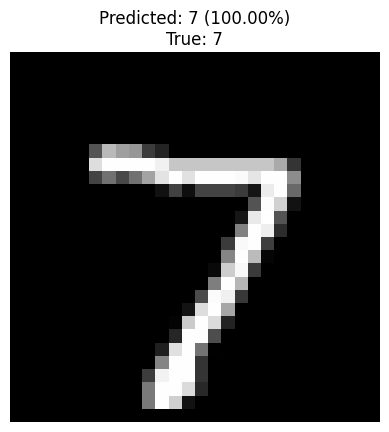

In [6]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()
N = 1 
examples_shown = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        confidences, predictions = torch.max(probs, 1)

        for i in range(inputs.size(0)):
            image = inputs[i].squeeze().numpy()  # remove channel dim
            true_label = labels[i].item()
            pred_label = predictions[i].item()
            confidence = confidences[i].item()

            # Plot the image
            plt.imshow(image, cmap='gray')
            plt.title(f"Predicted: {pred_label} ({confidence*100:.2f}%)\nTrue: {true_label}")
            plt.axis('off')
            plt.show()

            examples_shown += 1
            if examples_shown >= N:
                break
        if examples_shown >= N:
            break


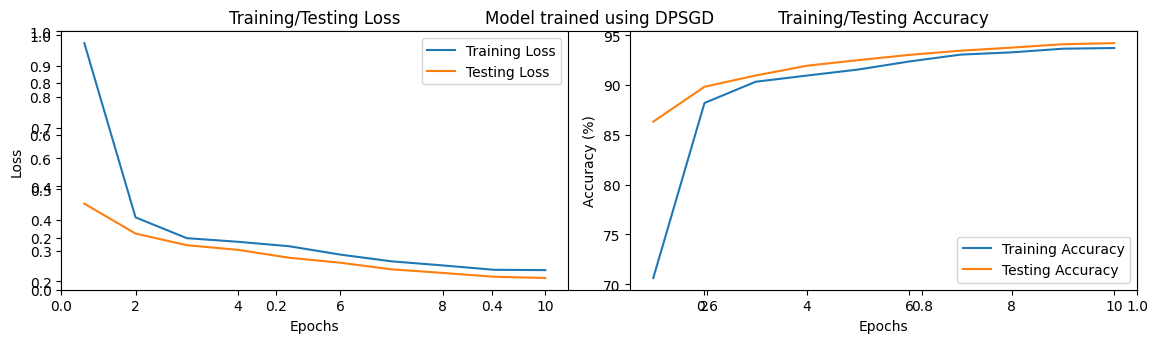

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.title('Model trained using DPSGD')
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training/Testing Accuracy')
plt.legend()

plt.tight_layout()
plt.show()